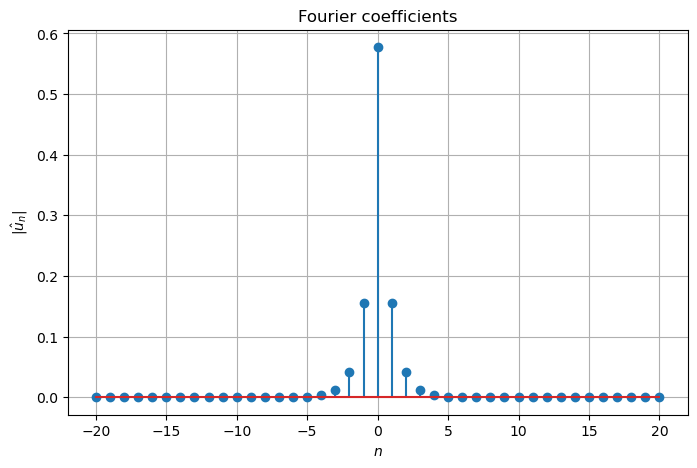

In [1]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(-20, 21)

u_hat = (1 / np.sqrt(3)) * (2 - np.sqrt(3))**np.abs(n)

plt.figure(figsize=(8, 5))
plt.stem(n, np.abs(u_hat))
plt.xlabel(r"$n$")
plt.ylabel(r"$|\hat{u}_n|$")
plt.title("Fourier coefficients")
plt.grid()
plt.show()

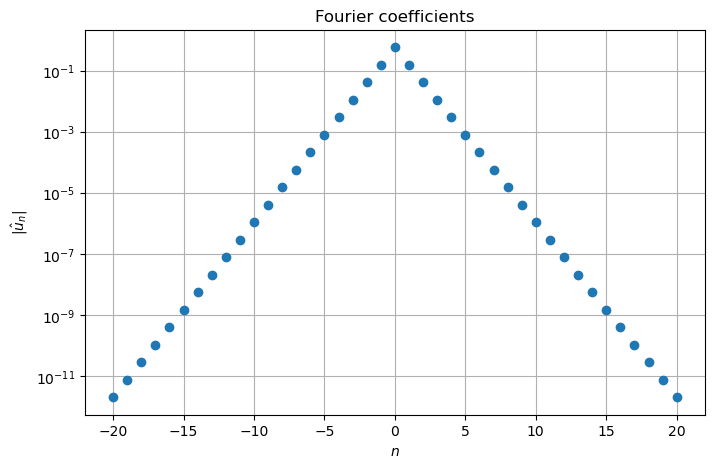

In [2]:
plt.figure(figsize=(8, 5))
plt.semilogy(n, np.abs(u_hat), "o")
plt.xlabel(r"$n$")
plt.ylabel(r"$|\hat{u}_n|$")
plt.title("Fourier coefficients")
plt.grid()
plt.show()

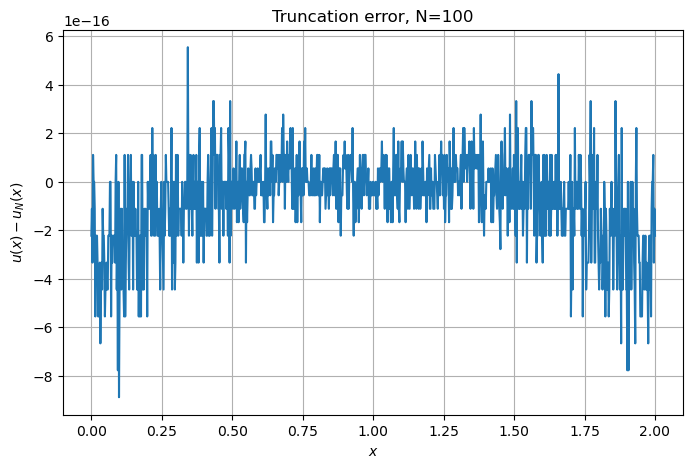

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def u(x):
    return 1 / (2 - np.cos(np.pi * x))

def u_hat(k):
    return (1 / np.sqrt(3)) * (2 - np.sqrt(3))**abs(k)

x = np.linspace(0, 2, 1000)

N = 100

u_trunc = np.zeros_like(x, dtype=complex)

for k in range(-N, N + 1):
    u_trunc += u_hat(k) * np.exp(1j * np.pi * k * x)

error = u(x) - u_trunc.real

plt.figure(figsize=(8, 5))
plt.plot(x, error)
plt.xlabel(r"$x$")
plt.ylabel(r"$u(x)-u_N(x)$")
plt.title(f"Truncation error, N={N}")
plt.grid()
plt.show()

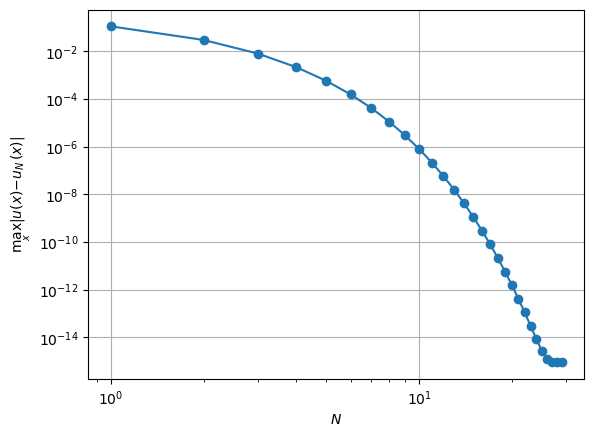

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def u(x):
    return 1 / (2 - np.cos(np.pi*x))

def u_hat(k):
    return (1 / np.sqrt(3)) * (2 - np.sqrt(3))**abs(k)

x = np.linspace(0, 2, 2000)

N_values = np.arange(1, 30)
errors = []

for N in N_values:

    u_N = np.zeros_like(x, dtype=complex)

    for k in range(-N, N + 1):
        u_N += u_hat(k) * np.exp(1j * np.pi * k * x)

    error = np.max(np.abs(u(x) - u_N.real))
    errors.append(error)

plt.loglog(N_values, errors, "o-")
plt.xlabel(r"$N$")
plt.ylabel(r"$\max_x |u(x)-u_N(x)|$")
plt.grid()
plt.show()

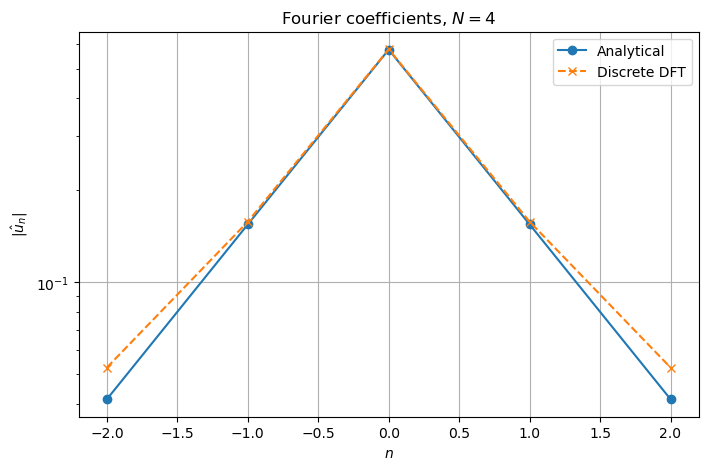

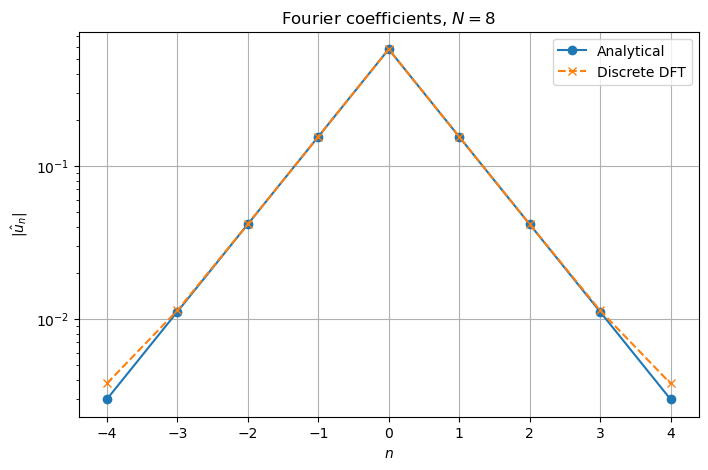

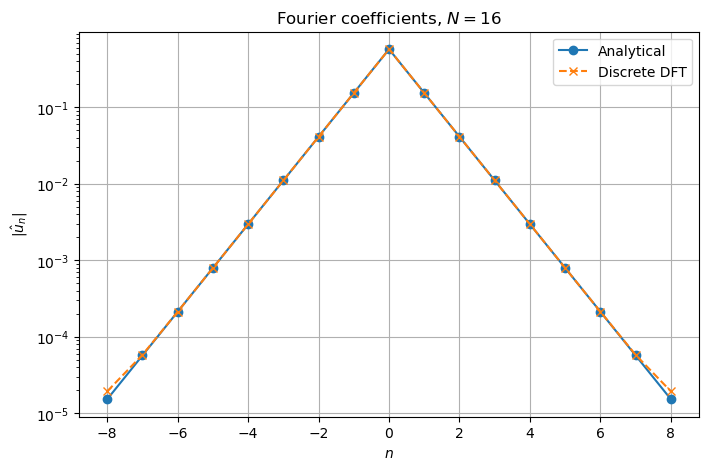

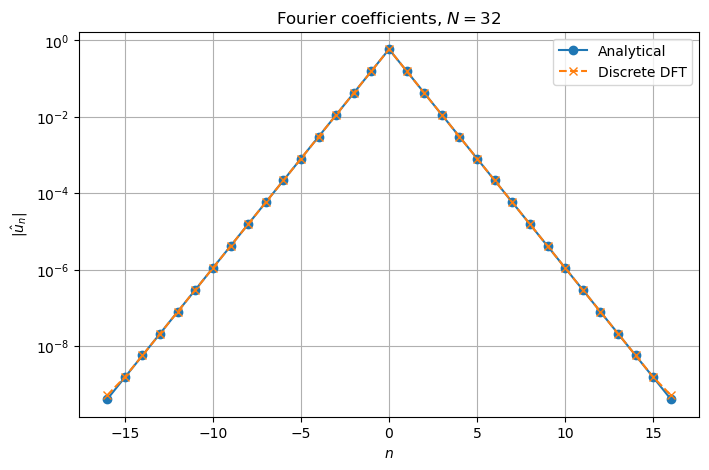

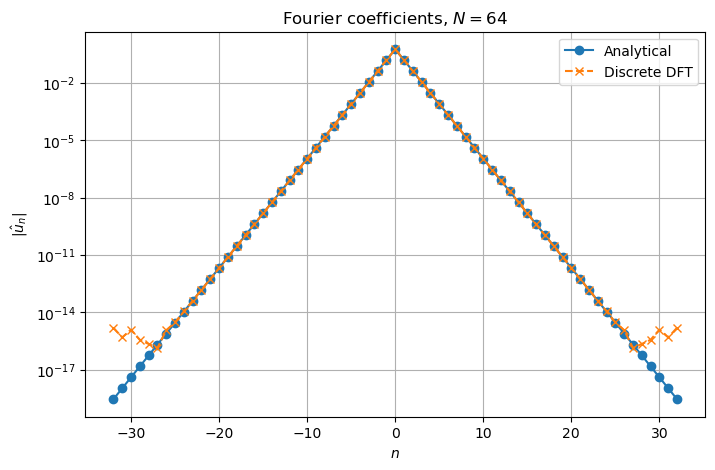

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def u(x):
    return 1 / (2 - np.cos(np.pi * x))

def u_hat(n):
    return (1 / np.sqrt(3)) * (2 - np.sqrt(3))**np.abs(n)


N_values = [4, 8, 16, 32, 64]

for N in N_values:

    # N+1 equally spaced points on [0,2)
    j = np.arange(N + 1)
    x = 2 * j / (N + 1)

    # Fourier modes
    n = np.arange(-N//2, N//2 + 1)

    # Discrete Fourier coefficients
    u_hat_discrete = np.zeros(len(n), dtype=complex)

    for i, k in enumerate(n):
        u_hat_discrete[i] = (
            1 / (N + 1)
            * np.sum(u(x) * np.exp(-1j * k * np.pi * x))
        )

    # Exact Fourier coefficients
    u_hat_exact = u_hat(n)

    # Plot
    plt.figure(figsize=(8, 5))

    plt.semilogy(
        n,
        np.abs(u_hat_exact),
        "o-",
        label="Analytical"
    )

    plt.semilogy(
        n,
        np.abs(u_hat_discrete),
        "x--",
        label="Discrete DFT"
    )

    plt.xlabel(r"$n$")
    plt.ylabel(r"$|\hat{u}_n|$")
    plt.title(fr"Fourier coefficients, $N={N}$")
    plt.grid()
    plt.legend()
    plt.show()

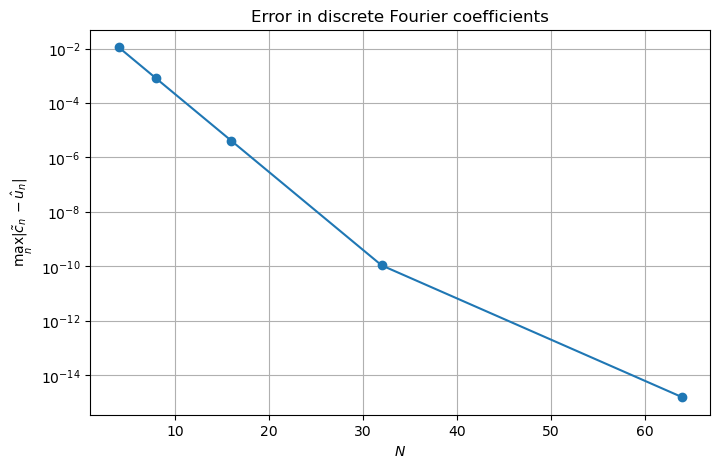

In [19]:
errors = []
N_values = [4, 8, 16, 32, 64]
for N in N_values:

    j = np.arange(N + 1)
    x = 2 * j / (N + 1)

    n = np.arange(-N//2, N//2 + 1)

    u_hat_discrete = np.zeros(len(n), dtype=complex)

    for i, k in enumerate(n):
        u_hat_discrete[i] = (
            1 / (N + 1)
            * np.sum(u(x) * np.exp(-1j * k * np.pi * x))
        )

    u_hat_exact = u_hat(n)

    error = np.max(np.abs(u_hat_discrete - u_hat_exact))

    errors.append(error)


plt.figure(figsize=(8, 5))

plt.semilogy(N_values, errors, "o-")

plt.xlabel(r"$N$")
plt.ylabel(r"$\max_n |\tilde{c}_n-\hat{u}_n|$")
plt.title("Error in discrete Fourier coefficients")

plt.grid()
plt.show()

<Figure size 800x500 with 0 Axes>

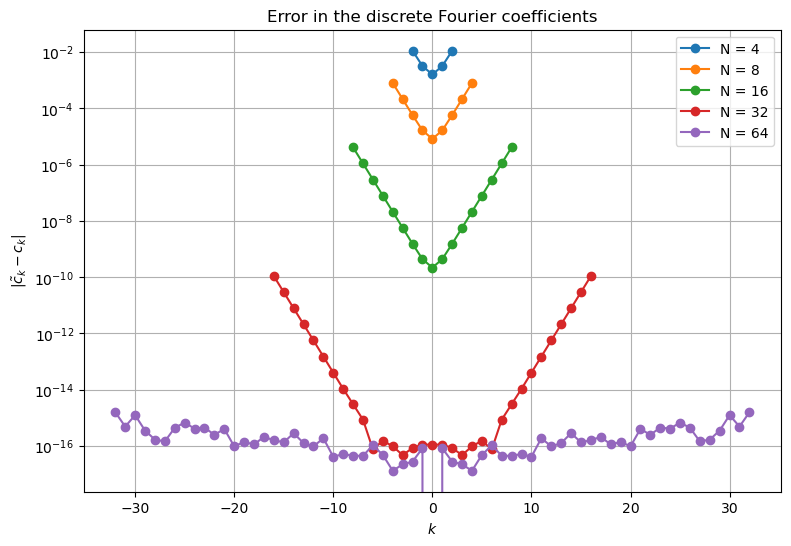

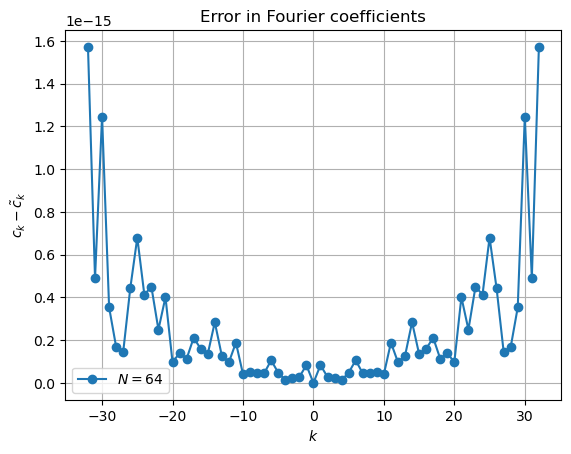

In [22]:
N_values = [4, 8, 16, 32, 64]

plt.figure(figsize=(8, 5))

for N in N_values:

    j = np.arange(N + 1)
    x = 2 * j / (N + 1)

    k = np.arange(-N//2, N//2 + 1)

    c_approx = np.zeros(len(k), dtype=complex)

    for i, n in enumerate(k):
        c_approx[i] = (
            1 / (N + 1)
            * np.sum(u(x) * np.exp(-1j * n * np.pi * x))
        )

    c_exact = u_hat(k)

    error = c_exact - c_approx
import numpy as np
import matplotlib.pyplot as plt

def u(x):
    return 1 / (2 - np.cos(np.pi * x))

def c_exact(k):
    return (1 / np.sqrt(3)) * (2 - np.sqrt(3))**np.abs(k)


N_values = [4, 8, 16, 32, 64]

plt.figure(figsize=(9, 6))

for N in N_values:

    # N+1 equally spaced nodes on [0,2)
    j = np.arange(N + 1)
    x = 2 * j / (N + 1)

    # Fourier modes
    k = np.arange(-N//2, N//2 + 1)

    # Discrete Fourier coefficients
    c_approx = np.zeros(len(k), dtype=complex)

    for i, n in enumerate(k):
        c_approx[i] = (
            1 / (N + 1)
            * np.sum(u(x) * np.exp(-1j * n * np.pi * x))
        )

    # Analytical coefficients
    c_analytical = c_exact(k)

    # Distance
    error = np.abs(c_approx - c_analytical)

    plt.semilogy(k, error, "o-", label=f"N = {N}")


plt.xlabel(r"$k$")
plt.ylabel(r"$|\tilde{c}_k-c_k|$")
plt.title("Error in the discrete Fourier coefficients")
plt.grid(True)
plt.legend()
plt.show()
plt.plot(k, error.real, "o-", label=fr"$N={N}$")

plt.xlabel(r"$k$")
plt.ylabel(r"$c_k-\tilde{c}_k$")
plt.title("Error in Fourier coefficients")
plt.grid()
plt.legend()
plt.show()

/var/folders/hx/228j6cc51r3gxlrh3q1dtnxw0000gn/T/ipykernel_54886/3839098891.py:12: RuntimeWarning: invalid value encountered in divide
  h = (1/N) * np.sin(N*s/2) / np.tan(s/2)


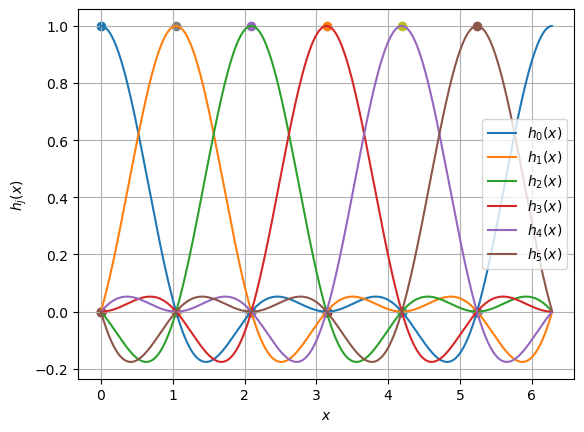

In [24]:
import numpy as np
import matplotlib.pyplot as plt

N = 6

xj = 2 * np.pi * np.arange(N) / N
x = np.linspace(0, 2*np.pi, 1000, endpoint=False)

for j in range(N):
    s = x - xj[j]

    h = (1/N) * np.sin(N*s/2) / np.tan(s/2)

    # removable singularity at x = x_j
    h[np.abs(s) < 1e-10] = 1.0

    plt.plot(x, h, label=fr"$h_{j}(x)$")

# mark interpolation nodes
for i in range(N):
    for j in range(N):
        value = 1 if i == j else 0
        plt.scatter(xj[i], value)

plt.xlabel(r"$x$")
plt.ylabel(r"$h_j(x)$")
plt.legend()
plt.grid()
plt.show()